In [1]:
from medtok import available_models, get_model, MODEL_REGISTRY



import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST, CIFAR100, CelebA
from medmnist import PathMNIST
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F
from dataset import MergedMedMNIST
from medmnist import INFO



### Prep Dataset ###
tensor_transforms = transforms.Compose(
    [
        transforms.Resize((128,128)),
        transforms.ToTensor(),
    ]
)

# train_set = MergedMedMNIST(root="/vol/miltank/users/bubeckn/MedMNIST", split="train", transform=tensor_transforms, download=False, size=224)
# test_set = MergedMedMNIST(root="/vol/miltank/users/bubeckn/MedMNIST", split="test", transform=tensor_transforms, download=False, size=224)

# train_set = PathMNIST(root="/vol/miltank/users/bubeckn/MedMNIST", split="train", transform=tensor_transforms, download=False, as_rgb=True, size=224)
# test_set = PathMNIST(root="/vol/miltank/users/bubeckn/MedMNIST", split="test", transform=tensor_transforms, download=False, as_rgb=True, size=224)

train_set = CIFAR100(root=".", train=True, transform=tensor_transforms, download=True)
test_set = CIFAR100(root=".", train=False, transform=tensor_transforms, download=True)

### Set Device ###
device = "cuda" if torch.cuda.is_available() else "cpu"

attention mode is flash


In [2]:
def train(model,
          train_set,
          test_set,
          batch_size,
          num_epochs,
          evaluation_iterations,
          step_break=100_000):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)

    trainloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=8)
    testloader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=8)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    train_losses = []
    evaluation_losses = []

    steps_per_epoch = len(trainloader)
    total_steps = steps_per_epoch * num_epochs
    step_counter = 0
    train_loss_running = []
    evaluation_loss_running = []

    with tqdm(total=num_epochs, desc="Epochs") as epoch_bar:
        for epoch in range(num_epochs):
            model.train()
            with tqdm(total=steps_per_epoch, desc=f"Epoch {epoch+1}/{num_epochs} | loss: N/A", leave=False) as pbar:
                for images, labels in trainloader:
                    # print(labels)
                    images = images.to(device)

                    recon, extra_loss = model(images)
                    loss = F.mse_loss(recon, images) +  extra_loss
                    # Update tqdm description with current loss value
                    pbar.set_description(f"Epoch {epoch+1}/{num_epochs} | loss: {loss.item():.4f}")

                    train_loss_running.append(loss.item())

                    loss.backward()
                    optimizer.step()
                    optimizer.zero_grad()

                    step_counter += 1
                    pbar.update(1)

                    if step_counter % step_break == 0:
                        break

                    # Evaluate every evaluation_iterations global step
                    if step_counter % evaluation_iterations == 0:
                        model.eval()
                        evaluation_loss_running.clear()
                        example_shown = False
                        with torch.no_grad():
                            for images_eval, labels_eval in testloader:
                                images_eval = images_eval.to(device)
                                recon_eval, _ = model(images_eval)
                                # Compute PSNR loss
                                mse = F.mse_loss(recon_eval, images_eval)
                                # Clamp to avoid log(0); add small epsilon
                                epsilon = 1e-8
                                psnr = 10 * torch.log10(1.0 / (mse + epsilon))
                                loss_eval = psnr
                                evaluation_loss_running.append(loss_eval.item())
                                
                                if not example_shown:

                                    def prep(img):
                                        img = img.detach().cpu()
                                        return img.squeeze(0) if img.shape[0] == 1 else img.permute(1, 2, 0)

                                    inp = prep(images_eval[0])
                                    rec = prep(recon_eval[0])
                                    cmap = "gray" if inp.ndim == 2 else None

                                    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
                                    titles = ["Input", "Reconstruction"]

                                    for ax, data, title in zip(axes, [inp, rec], titles):
                                        ax.imshow(data, cmap=cmap)
                                        ax.set_title(title)
                                        ax.axis("off")

                                    plt.suptitle(f"Eval Example at Step {step_counter}")
                                    plt.tight_layout()
                                    plt.show()

                                    example_shown = True
                        
                                break
                        model.train()
                        
            if step_counter % step_break == 0:
                break
            epoch_bar.update(1)
            



    return model, train_losses, evaluation_losses

('adm.classifier.128c', 'adm.classifier.256c', 'adm.classifier.512c', 'adm.classifier.64c', 'adm.diffusion.128c', 'adm.diffusion.128u', 'adm.diffusion.256c', 'adm.diffusion.256u', 'adm.diffusion.512c', 'adm.diffusion.512u', 'adm.diffusion.64c', 'adm.diffusion.64u', 'continuous.aekl.f16_d16', 'continuous.aekl.f16_d32', 'continuous.aekl.f16_d64', 'continuous.aekl.f16_d8', 'continuous.aekl.f32_d64', 'continuous.aekl.f4_d16', 'continuous.aekl.f4_d3', 'continuous.aekl.f4_d32', 'continuous.aekl.f4_d8', 'continuous.aekl.f8_d16', 'continuous.aekl.f8_d32', 'continuous.aekl.f8_d4', 'continuous.aekl.f8_d8', 'continuous.maisi.f4_d3', 'continuous.medvae.f8_d16', 'continuous.medvae.f8_d32', 'continuous.vavae.f16_d16_dinov2', 'continuous.vavae.f16_d16_mae', 'continuous.vavae.f16_d32_dinov2', 'continuous.vavae.f16_d32_mae', 'continuous.vavae.f16_d64_dinov2', 'continuous.vavae.f16_d64_mae', 'continuous.vavae.f8_d16_dinov2', 'continuous.vavae.f8_d32_dinov2', 'discrete.bsq.f16_d10_b10', 'discrete.bsq.f16

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100 | loss: N/A:   0%|          | 0/6250 [00:00<?, ?it/s]

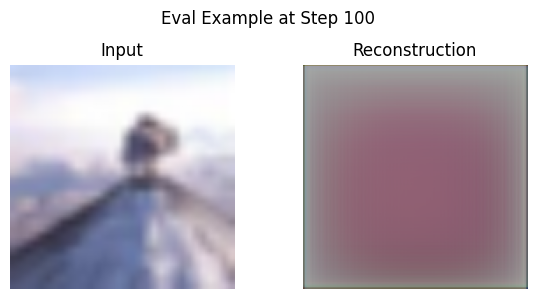

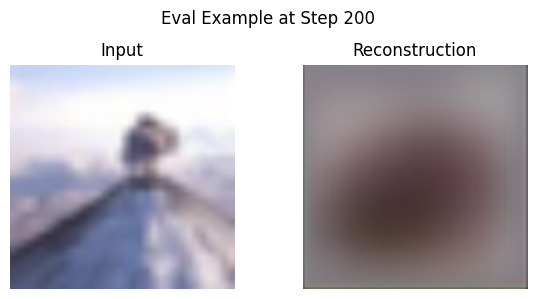

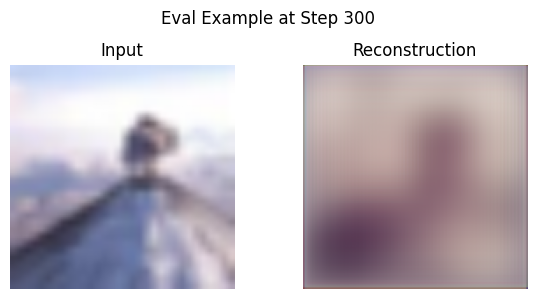

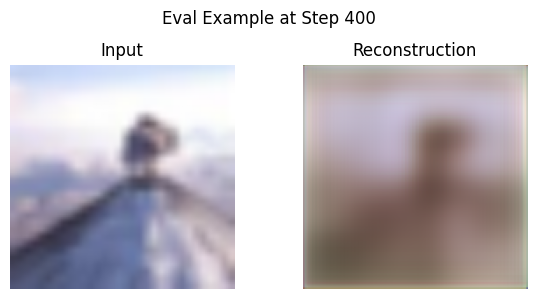

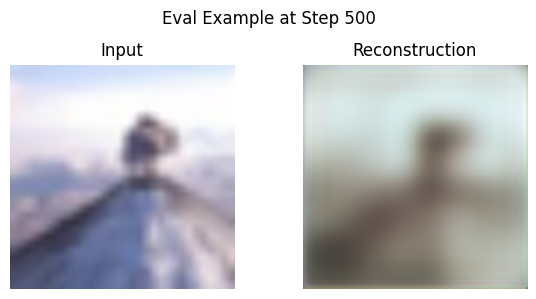

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.26486796..1.1212243].


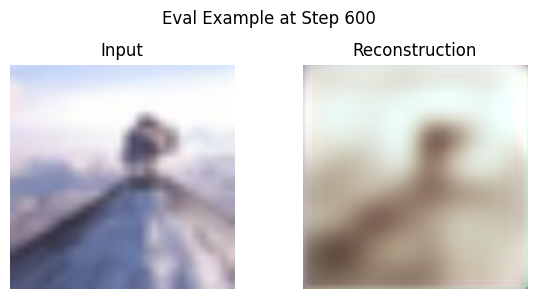

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.16493404..1.0639496].


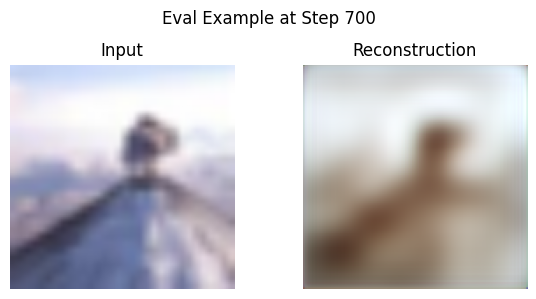

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.11571056..1.0687021].


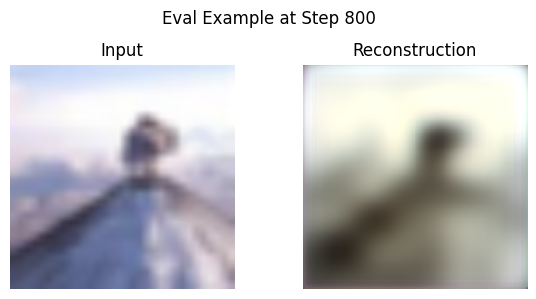

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.23676695..1.081586].


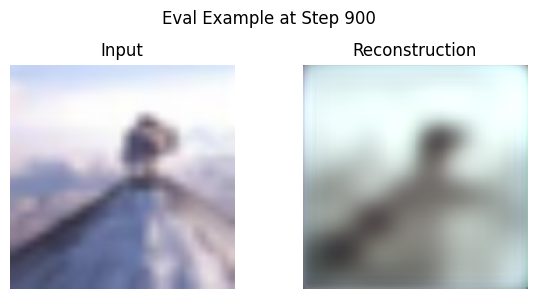

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.21208559..1.1050982].


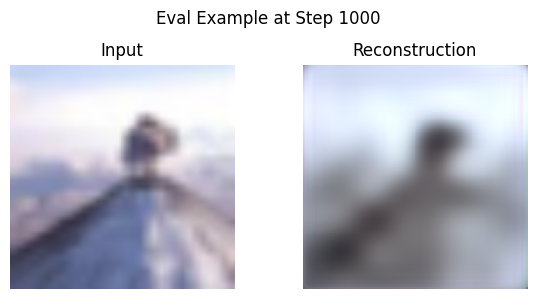

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.26974025..1.0297107].


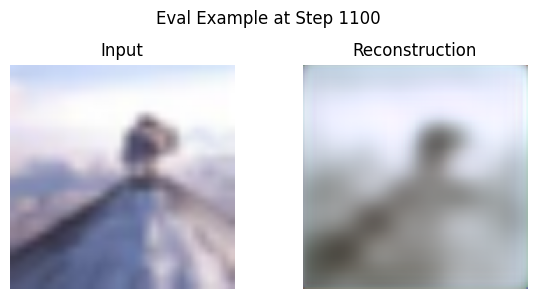

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2129129..1.0050218].


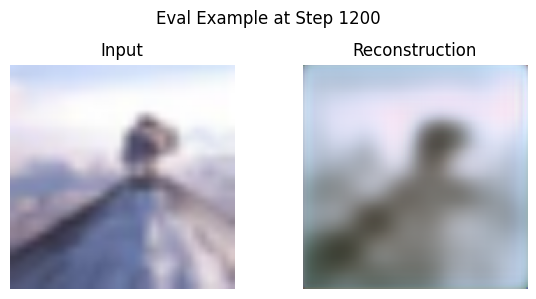

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2578574..1.0465622].


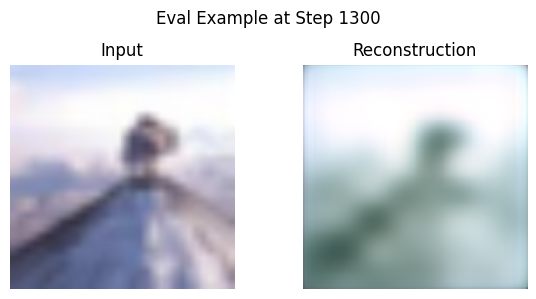

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.25411606..1.0156584].


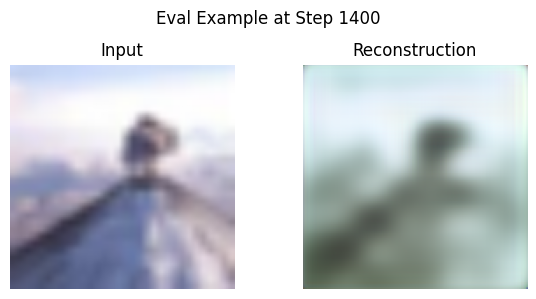

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.18026775..1.0017416].


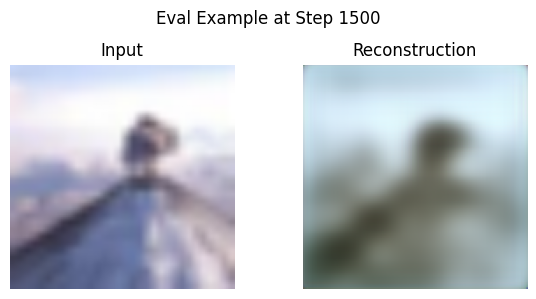

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.20922014..1.0427202].


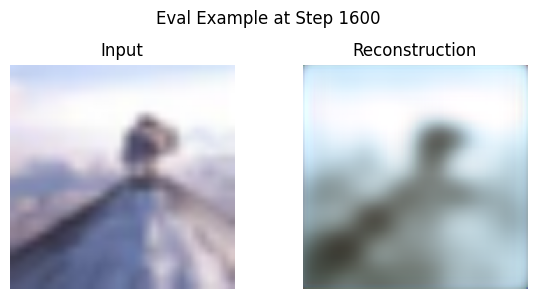

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1692328..1.0415316].


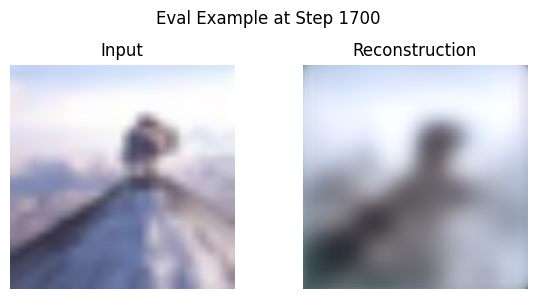

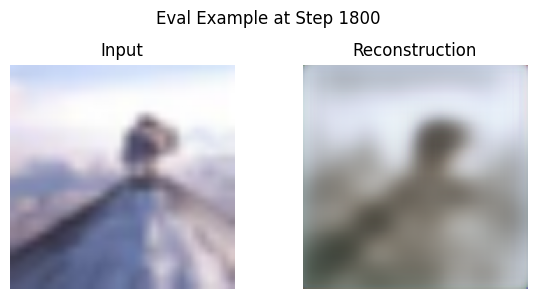

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.25634992..1.0768716].


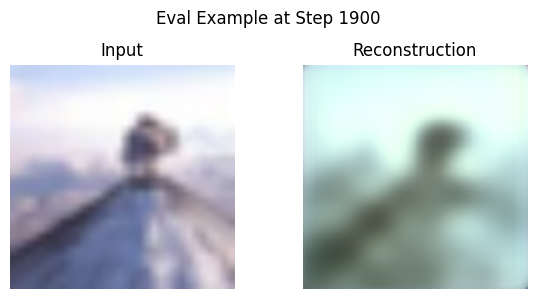

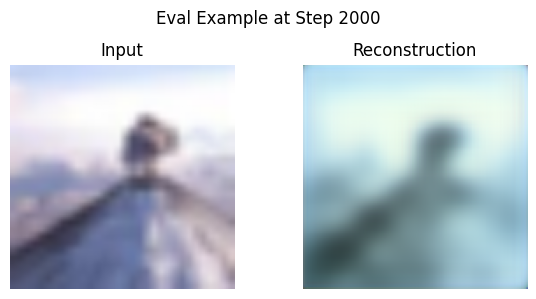

KeyboardInterrupt: 

: 

In [ ]:
all_models = available_models()
print(all_models)
f4_models = [name for name in all_models if "f4" in name]
print("All models with 'f4' in the name:", f4_models)

# model_list=[
# "continuous.aekl.f4_d3", "continuous.aekl.f8_d4", "continuous.aekl.f16_d8",
# "continuous.aekl.f4_d8", "continuous.aekl.f4_d16", "continuous.aekl.f4_d32",
# "continuous.aekl.f8_d8", "continuous.aekl.f8_d16", "continuous.aekl.f8_d32",
# "continuous.aekl.f16_d16", "continuous.aekl.f16_d32", "continuous.aekl.f16_d64",
# "continuous.medvae.f8_d16", "continuous.medvae.f8_d32", "continuous.vavae.f8_d16_dinov2", "continuous.vavae.f8_d32_dinov2",
# "discrete.lfq.f4_d10_b10", "discrete.lfq.f8_d14_b14", "discrete.lfq.f16_d18_b18",
# "discrete.bsq.f4_d10_b10", "discrete.bsq.f8_d14_b14", "discrete.bsq.f16_d18_b18",
# "discrete.simple_qinco.f16_d8_e16384", "discrete.simple_qinco.f4_d3_e8192", "discrete.simple_qinco.f8_d4_e16384",
# "discrete.simvq.f16_d8_e16384", "discrete.simvq.f4_d3_e8192", "discrete.simvq.f8_d4_e16384",
# "discrete.vq.f16_d8_e16384", "discrete.vq.f4_d3_e8192", "discrete.vq.f8_d4_e16384",
# "token.maetok.b_128", "token.maetok.b_256", "token.maetok.b_512",
# "token.titok.b_128_e2e", "token.titok.b_256_e2e", "token.titok.b_512_e2e",
# ]

model_list = [
    # "discrete.rqvae.f4_d3_e8192",
    # "discrete.rqvae.f8_d4_e16384",
    # "discrete.rqvae.f16_d8_e16384",
    # "discrete.qinco.f4_d3_e8192",
    # "discrete.qinco.f8_d4_e16384",
    # "discrete.qinco.f16_d8_e16384",
    "discrete.rsimple_qinco.f16_d8_e16384", "discrete.rsimple_qinco.f4_d3_e8192", "discrete.rsimple_qinco.f8_d4_e16384",
]

print(model_list.__len__())
for model_name in model_list:
    print(f"Training: ", model_name)
    f4 = get_model(model_name, img_size=224)

    linear_ae, train_losses, evaluation_losses = train(f4,
                                                    train_set=train_set,
                                                    test_set=test_set,
                                                    batch_size=8,
                                                    num_epochs=100,
                                                    evaluation_iterations=100)

In [ ]:
generated_index = 150
image, label = test_set[generated_index]

# Add batch dimension, move to device
image = image.unsqueeze(0).to(device)

# Forward pass
recon, _ = f4(image)

# Move to CPU, remove batch dim → shape: (C, H, W)
recon = recon.cpu().detach().squeeze()

# Convert to H×W×C (RGB) or H×W (grayscale)
if recon.ndim == 3:                 # C,H,W
    if recon.shape[0] == 1:         # grayscale
        recon = recon.squeeze(0)    # → H,W
        cmap = "gray"
    else:                           # RGB
        recon = recon.permute(1, 2, 0).numpy()
        cmap = None
else:
    cmap = "gray"

plt.imshow(recon, cmap=cmap)
plt.title("RVQVAE")
plt.axis("off")
plt.show()